# Lightweight IDS Using Machine Learning for IoT Devices
## Notebook 02: Data Cleaning, Feature Selection, Train/Test Split and SMOTE-ENN

**Author:** Mimi Nguyet Mi Taylor  
**Programme:** MSc Computer Science, Birkbeck, University of London  
**Supervisor:** Professor Paul Yoo

---

### About this notebook
This notebook continues from Notebook 01 and covers the remaining preprocessing steps:
1. Load the stratified sample (stratified_sample_1m.csv)
2. Data cleaning: missing values, duplicates, identifier column removal
3. Feature selection using Random Forest importance scores
4. Train/test split 70/30 stratified
5. SMOTE-ENN applied to training set only to correct class imbalance

### Input
stratified_sample_1m.csv (produced by Notebook 01)

### Output
- X_train_resampled.pkl
- y_train_resampled.pkl
- X_test.pkl
- y_test.pkl
- selected_features.pkl
- feature_importances.png
- smote_enn_balance.png

In [1]:
# Import all libraries needed for this notebook.
# pandas/numpy: data loading and manipulation
# matplotlib/seaborn: plotting
# joblib: saving data to disk
# sklearn: feature selection, train/test split, Random Forest
# imblearn: SMOTE-ENN for class imbalance correction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN

RANDOM_STATE = 42

print("All imports successful.")

All imports successful.


In [2]:
# Load the stratified sample created in Notebook 01.
# DATA_PATH is the full file path to the saved CSV file.
# This is the starting point for all cleaning and preprocessing steps.

DATA_PATH = os.path.expanduser("~/IDS_PROJECT_REPORT/stratified_sample_1m.csv")

df = pd.read_csv(DATA_PATH)

# Capture the original load count here, before cleaning steps below
# reuse and overwrite the df variable to keep record of what was actually loaded, for the notebook summary.
initial_rows = len(df)
initial_cols = df.shape[1]

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")
print(f"\nClass distribution (before cleaning):")
print(df['Category'].value_counts())

Loaded 1,000,000 rows and 41 columns.

Class distribution (before cleaning):
Category
DDoS              722718
DoS               172072
Mirai              56014
Benign             23354
Reconnaissance     14685
Spoofing           10350
Web-based            529
Brute Force          278
Name: count, dtype: int64


In [3]:
# Step 1: Check for missing values.
# Missing values can cause classifiers to crash or produce wrong results.

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

print(f"Columns with missing values: {len(missing_cols)}")
if len(missing_cols) > 0:
    print(missing_cols)

rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"\nRows removed due to missing values: {rows_before - rows_after:,}")
print(f"Rows remaining: {rows_after:,}")

Columns with missing values: 2
Std         14
Variance    14
dtype: int64

Rows removed due to missing values: 14
Rows remaining: 999,986


In [4]:
# Step 2: Remove duplicate rows.
# Duplicates can skew results by making the classifier see the same 
# record multiple times, artificially inflating performance.

rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"Duplicate rows removed: {rows_before - rows_after:,}")
print(f"Rows remaining: {rows_after:,}")

Duplicate rows removed: 268,771
Rows remaining: 731,215


In [5]:
# Step 3: Remove identifier columns.
# Columns like IP addresses and timestamps are specific to the lab 
# environment where CICIoT2023 was recorded. If we keep them, the 
# classifier learns to recognise the lab, not real attack patterns.
# They must be removed so the model generalises to unseen traffic.

print("All columns:")
print(df.columns.tolist())

All columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label', 'Category']


In [6]:
# Remove the Label column. This was the original raw attack label 
# (e.g. DDOS-ICMP_FLOOD) which we mapped to Category in Notebook 01.
# Label must be removed because it would give the classifier a direct
# clue about the answer, making results meaningless.
# Category is our target variable and is kept separately below.
# Note: total columns drops from 41 to 40 here, since Label is removed.

df = df.drop(columns=['Label'])

print(f"Columns remaining: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")

Columns remaining: 40
Columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Category']


In [7]:
# Separate features (X) and target label (y).
# X contains everything we use to make predictions (the 39 feature columns).
# y contains what we are trying to predict (the attack category).
# We also replace any infinite values with NaN and drop those rows.
# Infinite values appear in some network flow features due to division 
# by zero in flow rate calculations and will crash most classifiers.
# Note: total columns drops from 40 to 39 here, since Category is separated out into y.

X = df.drop(columns=['Category'])
y = df['Category']

# Check for infinite values
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f"Infinite values found: {inf_count}")

X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f"Rows remaining after removing infinite values: {len(X):,}")
print(f"\nFinal class distribution after cleaning:")
print(y.value_counts())

Infinite values found: 10
Rows remaining after removing infinite values: 731,205

Final class distribution after cleaning:
Category
DDoS              487346
DoS               139145
Mirai              55876
Benign             23342
Reconnaissance     14675
Spoofing           10014
Web-based            529
Brute Force          278
Name: count, dtype: int64


In [8]:
# Feature selection using Random Forest importance scores.
# We train a small Random Forest purely to score how useful each 
# feature is for predicting attack category.
# Features with very low importance scores add noise and slow down 
# all classifiers without improving accuracy.
# Random Forest is used here because Phan et al. (2024) found it 
# the most stable feature selection method across all classifiers 
# on CICIoT2023.

print("Training Random Forest for feature importance scoring...")
print("This may take a few minutes.")

X_numeric = X.select_dtypes(include=[np.number])

rf_selector = RandomForestClassifier(
    n_estimators=50,    # 50 trees is enough for importance scoring
    max_depth=10,       # shallow trees are faster
    random_state=RANDOM_STATE,
    n_jobs=-1           # use all CPU cores
)
rf_selector.fit(X_numeric, y)

importances = pd.Series(rf_selector.feature_importances_, index=X_numeric.columns)
importances = importances.sort_values(ascending=False)

print(f"\nTop 20 features by importance:")
print(importances.head(20))

Training Random Forest for feature importance scoring...
This may take a few minutes.

Top 20 features by importance:
Tot sum            0.117622
Tot size           0.113498
AVG                0.110445
Protocol Type      0.065786
Max                0.059502
Std                0.052662
Number             0.046959
Header_Length      0.043671
Rate               0.042872
Min                0.039070
ICMP               0.029800
ack_flag_number    0.028626
Variance           0.026528
TCP                0.023966
psh_flag_number    0.023788
ack_count          0.023536
Time_To_Live       0.020903
HTTPS              0.020074
IAT                0.019504
UDP                0.018285
dtype: float64


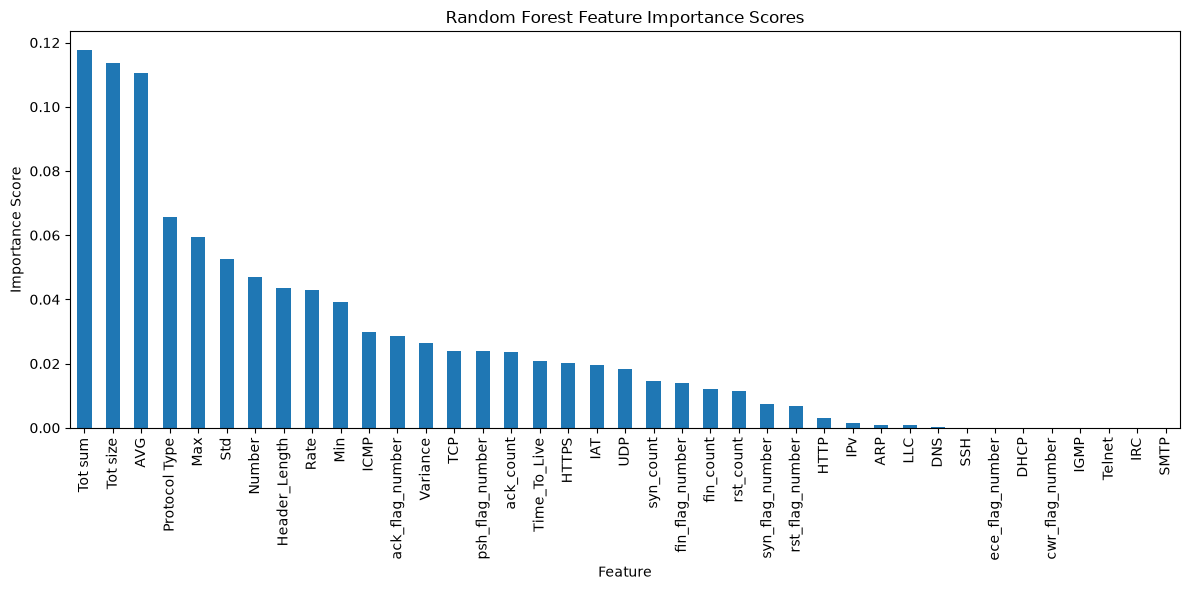

Plot saved.


In [9]:
# Plot feature importance scores for all features.
# This helps us decide where to set the threshold for feature selection.
# This figure will be included in the report.

plt.figure(figsize=(12, 6))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importance Scores')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.expanduser("~/IDS_PROJECT_REPORT/feature_importances.png"), dpi=150)
plt.show()
print("Plot saved.")

In [10]:
# Keep only features with importance score above 0.025 (2.5%).
# The literature shows the feature space can be reduced to between 
# 5 and 13 features without performance loss on CICIoT2023
# (Phan et al., 2024; Al-Ashmali et al., 2025).

THRESHOLD = 0.025

selected_features = importances[importances >= THRESHOLD].index.tolist()
print(f"Features selected (importance >= {THRESHOLD}): {len(selected_features)}")
print(selected_features)

X_selected = X_numeric[selected_features]

joblib.dump(selected_features, os.path.expanduser("~/IDS_PROJECT_REPORT/selected_features.pkl"))
print("\nSelected feature list saved.")

Features selected (importance >= 0.025): 13
['Tot sum', 'Tot size', 'AVG', 'Protocol Type', 'Max', 'Std', 'Number', 'Header_Length', 'Rate', 'Min', 'ICMP', 'ack_flag_number', 'Variance']

Selected feature list saved.


In [11]:
# Split data into training (70%) and test (30%) sets.
# Stratified splitting preserves class proportions in both sets.
# This is consistent with Phan et al. (2024) on the same dataset,
# making our results directly comparable.
# SMOTE-ENN will only be applied to the training set.
# The test set stays as real records to prevent data leakage.

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size:     {len(X_test):,}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 511,843
Test set size:     219,362

Training set class distribution:
Category
DDoS              341142
DoS                97401
Mirai              39113
Benign             16339
Reconnaissance     10273
Spoofing            7010
Web-based            370
Brute Force          195
Name: count, dtype: int64

Test set class distribution:
Category
DDoS              146204
DoS                41744
Mirai              16763
Benign              7003
Reconnaissance      4402
Spoofing            3004
Web-based            159
Brute Force           83
Name: count, dtype: int64


In [12]:
# Apply SMOTE-ENN to the training set only.
# SMOTE creates synthetic examples of minority classes.
# ENN removes noisy majority class examples.
# Applied to training set only to prevent data leakage.
# Al-Ashmali et al. (2025) found SMOTE-ENN achieved the highest 
# F1-score of 0.9998 on CICIoT2023 across all resampling methods.

print("Applying SMOTE-ENN to training set only.")

smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

print(f"\nTraining set size before SMOTE-ENN: {len(X_train):,}")
print(f"Training set size after SMOTE-ENN:  {len(X_train_resampled):,}")
print(f"\nResampled training class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Applying SMOTE-ENN to training set only.

Training set size before SMOTE-ENN: 511,843
Training set size after SMOTE-ENN:  2,273,555

Resampled training class distribution:
Category
Mirai             340044
Brute Force       329593
Web-based         323178
Spoofing          312879
Reconnaissance    307792
Benign            295385
DDoS              195702
DoS               168982
Name: count, dtype: int64


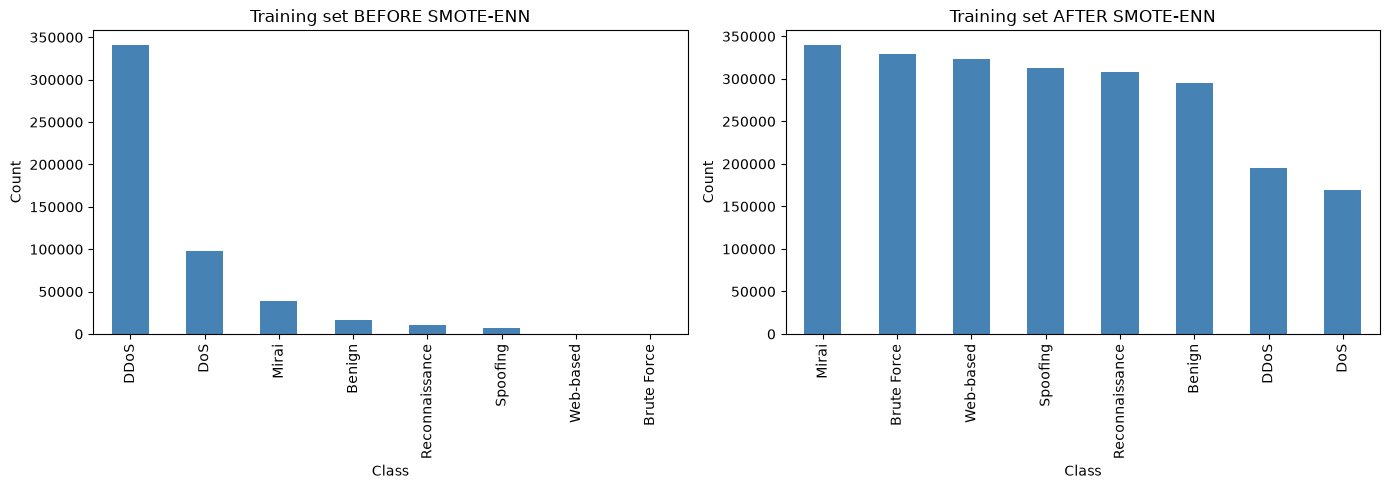

Plot saved.


In [13]:
# Visual check that SMOTE-ENN balanced the classes correctly.
# This figure will appear in the report as evidence of correct preprocessing.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], 
    title='Training set BEFORE SMOTE-ENN', color='steelblue')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1], 
    title='Training set AFTER SMOTE-ENN', color='steelblue')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/IDS_PROJECT_REPORT/smote_enn_balance.png"), dpi=150)
plt.show()
print("Plot saved.")

In [14]:
# Save all outputs to disk for use in Notebook 03 (model training).
# joblib handles large numpy arrays.

OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

joblib.dump(X_train_resampled, OUTPUT_DIR + "X_train_resampled.pkl")
joblib.dump(y_train_resampled, OUTPUT_DIR + "y_train_resampled.pkl")
joblib.dump(X_test,            OUTPUT_DIR + "X_test.pkl")
joblib.dump(y_test,            OUTPUT_DIR + "y_test.pkl")

print("Saved:")
print(f"  X_train_resampled: {X_train_resampled.shape}")
print(f"  y_train_resampled: {len(y_train_resampled):,}")
print(f"  X_test:            {X_test.shape}")
print(f"  y_test:            {len(y_test):,}")

Saved:
  X_train_resampled: (2273555, 13)
  y_train_resampled: 2,273,555
  X_test:            (219362, 13)
  y_test:            219,362


---
## Lightweight checks
 

In [15]:
# Lightweight checks across the full data preprocessing and cleaning pipeline.

assert 'Label' not in df.columns, "Label column should have been dropped"
assert X.isnull().sum().sum() == 0, "X should contain no missing values"
assert not np.isinf(X.select_dtypes(include=[np.number])).values.any(), "X should contain no infinite values"
assert len(X) == len(y), "X and y must have the same number of rows"
assert len(selected_features) == X_selected.shape[1], "Selected feature count does not match X_selected columns"
assert len(X_train) + len(X_test) == len(X_selected), "Train/test split does not sum to full dataset"
assert X_train_resampled.shape[0] == len(y_train_resampled), "X_train_resampled and y_train_resampled length mismatch"

print("All checks passed.")

All checks passed.


---
## Summary
 

In [16]:
print(f"{'Step':<10} {'Description':<45} {'Result'}")
print("-" * 100)
print(f"{'Load':<10} {'Stratified sample loaded from Notebook 01':<55} {initial_rows:,} rows, {initial_cols} columns")
print(f"{'Clean':<10} {'Missing values, duplicates, infinite values removed':<55} {len(X):,} rows remaining")
print(f"{'Select':<10} {'Random Forest importance, threshold 0.025':<55} {len(selected_features)} features selected (from 39)")
print(f"{'Split':<10} {'70/30 stratified train/test split':<55} {len(X_train):,} training, {len(X_test):,} test")
print(f"{'Resample':<10} {'SMOTE-ENN applied to training set only':<55} {len(X_train_resampled):,} training records after resampling")
print(f"{'Save':<10} {'Preprocessed data saved for Notebook 03':<55} 5 files saved to OUTPUT_DIR")

Step       Description                                   Result
----------------------------------------------------------------------------------------------------
Load       Stratified sample loaded from Notebook 01               1,000,000 rows, 41 columns
Clean      Missing values, duplicates, infinite values removed     731,205 rows remaining
Select     Random Forest importance, threshold 0.025               13 features selected (from 39)
Split      70/30 stratified train/test split                       511,843 training, 219,362 test
Resample   SMOTE-ENN applied to training set only                  2,273,555 training records after resampling
Save       Preprocessed data saved for Notebook 03                 5 files saved to OUTPUT_DIR
